In [ ]:
Задание 9. Вариант 3 Выполнил: Радченко Анатолий Группа: МГК-53

Размер данных: (1797, 64)
Количество классов: 10
Распределение классов:
 0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64


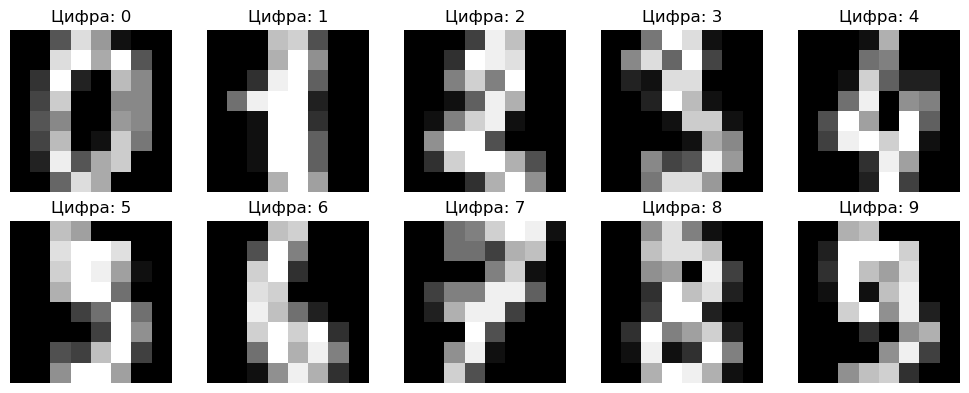

Обучающая выборка: (1437, 64)
Тестовая выборка: (360, 64)
=== Одиночное дерево решений ===
Accuracy: 0.8250
              precision    recall  f1-score   support

           0       0.92      0.97      0.95        36
           1       0.84      0.72      0.78        36
           2       0.78      0.80      0.79        35
           3       0.79      0.81      0.80        37
           4       0.86      0.86      0.86        36
           5       0.88      0.95      0.91        37
           6       0.81      0.83      0.82        36
           7       0.84      0.86      0.85        36
           8       0.71      0.69      0.70        35
           9       0.82      0.75      0.78        36

    accuracy                           0.82       360
   macro avg       0.82      0.82      0.82       360
weighted avg       0.82      0.82      0.82       360



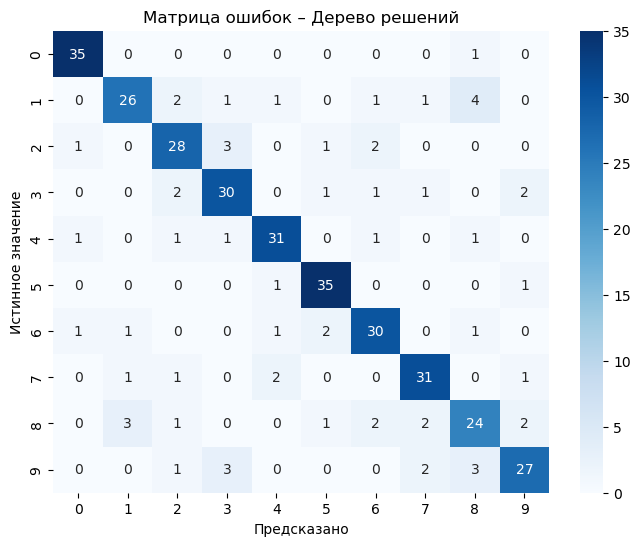

=== Случайный лес (по умолчанию) ===
Accuracy: 0.9611
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        36
           1       0.90      0.97      0.93        36
           2       1.00      0.97      0.99        35
           3       0.97      0.97      0.97        37
           4       0.97      0.97      0.97        36
           5       0.97      1.00      0.99        37
           6       1.00      0.97      0.99        36
           7       0.92      1.00      0.96        36
           8       0.94      0.86      0.90        35
           9       0.97      0.92      0.94        36

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360

Fitting 5 folds for each of 18 candidates, totalling 90 fits

=== Результаты GridSearchCV ===
Лучшие гиперпараметры: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Лучшая 

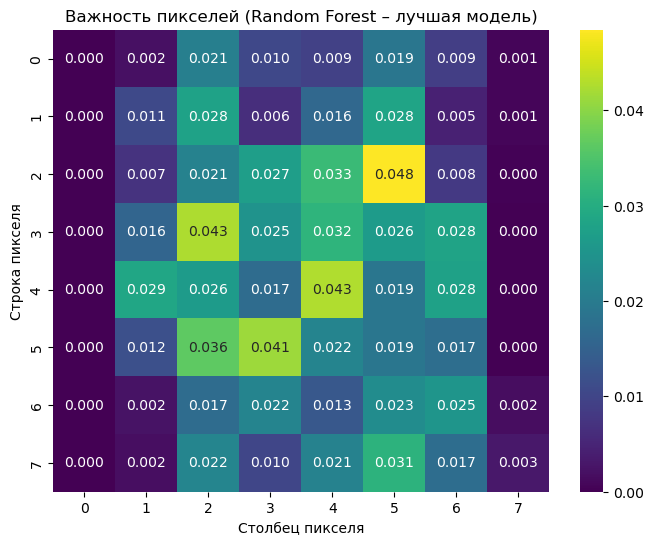

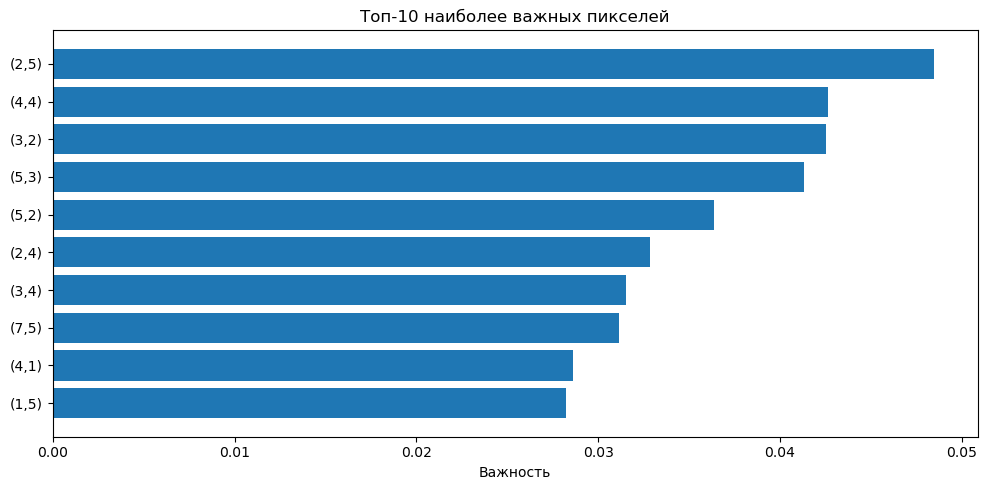

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


digits = load_digits()
X = digits.data
y = digits.target
feature_names = [f"pixel_{i}" for i in range(64)]  # для справки
target_names = digits.target_names

print("Размер данных:", X.shape)
print("Количество классов:", len(target_names))
print("Распределение классов:\n", pd.Series(y).value_counts().sort_index())


fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"Цифра: {y[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")


tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

acc_tree = accuracy_score(y_test, y_pred_tree)
print("=== Одиночное дерево решений ===")
print(f"Accuracy: {acc_tree:.4f}")
print(classification_report(y_test, y_pred_tree, target_names=[str(i) for i in target_names]))


cm_tree = confusion_matrix(y_test, y_pred_tree)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.title('Матрица ошибок – Дерево решений')
plt.xlabel('Предсказано')
plt.ylabel('Истинное значение')
plt.show()


rf_default = RandomForestClassifier(random_state=42)
rf_default.fit(X_train, y_train)
y_pred_rf_default = rf_default.predict(X_test)

acc_rf_default = accuracy_score(y_test, y_pred_rf_default)
print("=== Случайный лес (по умолчанию) ===")
print(f"Accuracy: {acc_rf_default:.4f}")
print(classification_report(y_test, y_pred_rf_default, target_names=[str(i) for i in target_names]))


param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("\n=== Результаты GridSearchCV ===")
print(f"Лучшие гиперпараметры: {grid_search.best_params_}")
print(f"Лучшая точность на кросс-валидации: {grid_search.best_score_:.4f}")


best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
acc_best = accuracy_score(y_test, y_pred_best)

print(f"Точность лучшей модели на тесте: {acc_best:.4f}")


print("\nClassification Report (лучшая модель):")
print(classification_report(y_test, y_pred_best, target_names=[str(i) for i in target_names]))


print("\n=== Сравнение точности (Accuracy) ===")
print(f"Одиночное дерево решений:     {acc_tree:.4f}")
print(f"Случайный лес (по умолчанию): {acc_rf_default:.4f}")
print(f"Случайный лес (GridSearchCV): {acc_best:.4f}")
print(f"Улучшение за счёт подбора:    {acc_best - acc_rf_default:.4f}")


importances = best_rf.feature_importances_

importance_image = importances.reshape(8, 8)

plt.figure(figsize=(8, 6))
sns.heatmap(importance_image, annot=True, fmt=".3f", cmap='viridis', 
            xticklabels=range(8), yticklabels=range(8))
plt.title('Важность пикселей (Random Forest – лучшая модель)')
plt.xlabel('Столбец пикселя')
plt.ylabel('Строка пикселя')
plt.show()

top_indices = np.argsort(importances)[-10:][::-1]
top_importances = importances[top_indices]
top_pixels = [f"({i//8},{i%8})" for i in top_indices]

plt.figure(figsize=(10, 5))
plt.barh(range(10), top_importances)
plt.yticks(range(10), top_pixels)
plt.xlabel('Важность')
plt.title('Топ-10 наиболее важных пикселей')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()